## 3.1 Markovian drone

**(a)**

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

n=20
drone_pos=np.array((0,0))
goal_pos=np.array((19,9))
x_eye=np.array((15,15))
sigma=10
gamma=0.95
Value_function=np.zeros((20,20))
previous_value_function=np.zeros((20,20))


actions={"up": np.array((0,1)),
         "down": np.array((0,-1)),
         "left": np.array((-1,0)),
         "right": np.array((1,0))}  


def move_drone(pos,action):
    new_pos=pos+actions[action]
    if (0<=new_pos[0]<n) and (0<=new_pos[1]<n):
        return new_pos
    else:
        return pos
def get_reward(pos):
    return float(np.all(pos==goal_pos))

def get_neighboring_positions(pos):
    neighbors={}
    for action in actions.keys():
        neighbors[action]=move_drone(pos,action)
    return neighbors

def w(pos,x_eye):
    distance=np.linalg.norm(pos-x_eye)
    return np.exp(-distance**2/(2*sigma**2))

def is_intended_action(action,intent):
    return action==intent

def update_value_function():
    V=Value_function.copy()
    for x in range(n):
        for y in range(n):
            pos=np.array((x,y))
            storm_prob=w(pos,x_eye)
            neighbors=get_neighboring_positions(pos)
            value_update=-np.inf
            for intent in actions.keys():
                value_candidate=np.sum([(storm_prob/4 + (1-storm_prob)*is_intended_action(a,intent))*(get_reward(neighbors[a]) + gamma*V[tuple(neighbors[a])]) for a in actions.keys()])
                if value_candidate>value_update:
                    value_update=value_candidate
            Value_function[x,y]=value_update

Loss: 0.713082
Loss: 0.676943
Loss: 0.646419
Loss: 0.630601
Loss: 0.614890
Loss: 0.604435
Loss: 0.593896
Loss: 0.585945
Loss: 0.578136
Loss: 0.571831
Loss: 0.565879
Loss: 0.560203
Loss: 0.554378
Loss: 0.548251
Loss: 0.541661
Loss: 0.534460
Loss: 0.526685
Loss: 0.518230
Loss: 0.509229
Loss: 0.499621
Loss: 0.489572
Loss: 0.479057
Loss: 0.468241
Loss: 0.457119
Loss: 0.445831
Loss: 0.434386
Loss: 0.422897
Loss: 0.411374
Loss: 0.399905
Loss: 0.388492
Loss: 0.377185
Loss: 0.365983
Loss: 0.354903
Loss: 0.343936
Loss: 0.333075
Loss: 0.322291
Loss: 0.311611
Loss: 0.301033
Loss: 0.290554
Loss: 0.280196
Loss: 0.269949
Loss: 0.259852
Loss: 0.249958
Loss: 0.240260
Loss: 0.230782
Loss: 0.221519
Loss: 0.212528
Loss: 0.203800
Loss: 0.195343
Loss: 0.187148
Loss: 0.179228
Loss: 0.171599
Loss: 0.164238
Loss: 0.157143
Loss: 0.150299
Loss: 0.143705
Loss: 0.137359
Loss: 0.131256
Loss: 0.125382
Loss: 0.119731
Loss: 0.114295
Loss: 0.109071
Loss: 0.104050
Loss: 0.099228
Loss: 0.094601
Loss: 0.090159
Loss: 0.08

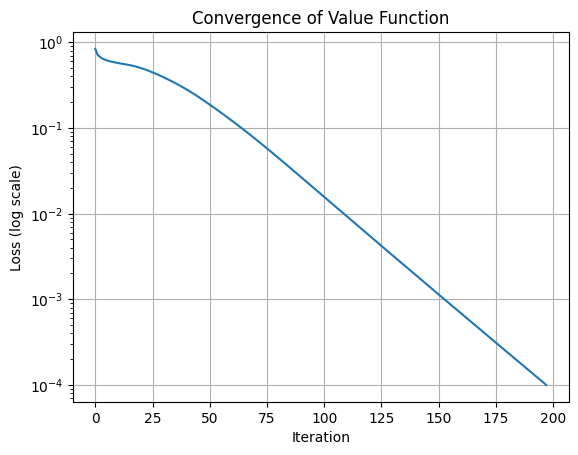

In [2]:
# Value iteration until convergence
update_value_function()
loss=np.linalg.norm(Value_function-previous_value_function)
history=[loss]
while not loss<1e-4:
    previous_value_function=Value_function.copy()
    update_value_function() 
    loss=np.linalg.norm(Value_function-previous_value_function)
    history.append(loss)
    print(f"Loss: {loss:.6f}")
plt.plot(history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('Convergence of Value Function')
plt.grid()
plt.show()

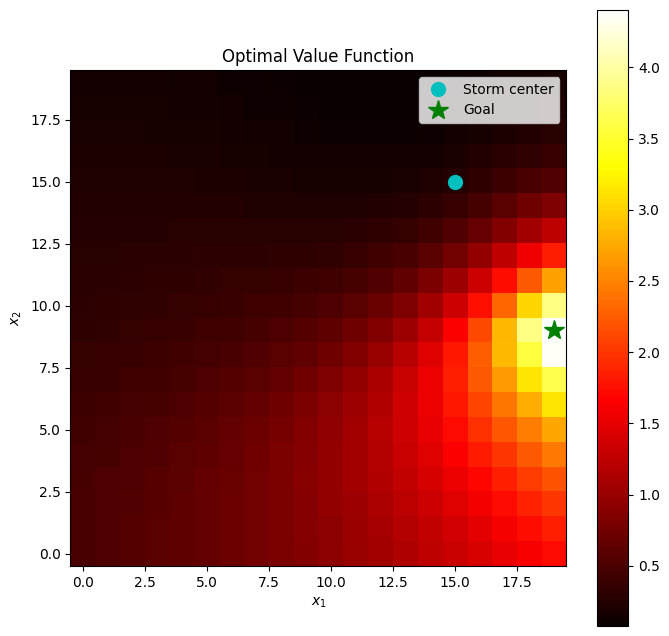

In [3]:
# Heatmap of optimal value function
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(Value_function.T, origin='lower', cmap='hot')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Optimal Value Function')
ax.plot(x_eye[0], x_eye[1], 'co', markersize=10, label='Storm center')
ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=15, label='Goal')
ax.legend()
plt.colorbar(im, ax=ax)
plt.show()

**(b)**

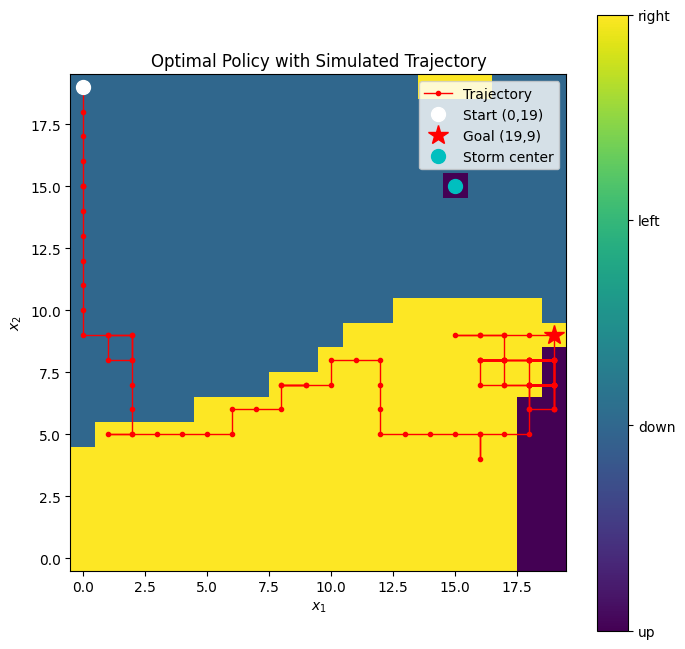

In [4]:
# (b) Compute optimal policy
action_names = list(actions.keys())  # ['up', 'down', 'left', 'right'] -> [0, 1, 2, 3]
policy = np.zeros((n, n), dtype=int)

for x in range(n):
    for y in range(n):
        pos = np.array((x, y))
        storm_prob = w(pos, x_eye)
        neighbors = get_neighboring_positions(pos)
        best_value = -np.inf
        for idx, intent in enumerate(action_names):
            value_candidate = sum(
                (storm_prob/4 + (1 - storm_prob) * is_intended_action(a, intent)) *
                (get_reward(neighbors[a]) + gamma * Value_function[tuple(neighbors[a])])
                for a in action_names
            )
            if value_candidate > best_value:
                best_value = value_candidate
                policy[x, y] = idx

# Simulate from (0, 19) for 100 steps
np.random.seed(42)
pos = np.array([0, 19])
trajectory = [pos.copy()]
for _ in range(100):
    action = action_names[policy[pos[0], pos[1]]]
    omega = w(pos, x_eye)
    if np.random.rand() < omega:
        action = np.random.choice(action_names)
    pos = move_drone(pos, action)
    trajectory.append(pos.copy())
trajectory = np.array(trajectory)

# Plot policy heatmap with trajectory overlay
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(policy.T, origin='lower', cmap='viridis')
ax.plot(trajectory[:, 0], trajectory[:, 1], 'r-o', markersize=3, linewidth=1, label='Trajectory')
ax.plot(trajectory[0, 0], trajectory[0, 1], 'wo', markersize=10, label='Start (0,19)')
ax.plot(goal_pos[0], goal_pos[1], 'r*', markersize=15, label='Goal (19,9)')
ax.plot(x_eye[0], x_eye[1], 'co', markersize=10, label='Storm center')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Optimal Policy with Simulated Trajectory')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['up', 'down', 'left', 'right'])
ax.legend()
plt.show()

The policy steers the drone toward the goal at $(19, 9)$ while avoiding the storm center at $(15, 15)$. Far from the storm, the drone moves directly toward the goal. Near the storm, where the probability of being blown in a random direction is high, the policy routes the drone around the storm from below rather than going through it.